# CS613 Final Project

## Random Forest Model

In [54]:
import numpy as np
import pandas as pd

#Reads in the data and drops the first row
df = pd.read_csv('data/nfl_data.csv')

#List of columns to exclude. These columns are either irrelevant to the outcome of the game or would result in data leakage (home_score and away_score)
exclude = ['game_id', 'season', 'season_type', 'week', 'team_home', 'season_type_home', 'opponent_team_home', 'id', 
           'week_away', 'team_away', 'opponent_team_away', 'home_team', 'away_team', 
           'home_score', 'away_score', 'fg_made_list_home', 'fg_missed_list_home', 'fg_made_list_away', 'fg_missed_list_away',
          'fg_blocked_list_away']

data = df.loc[:, ~df.columns.isin(exclude)].to_numpy()

### 2. Shuffle The Observations

In [4]:
#Sets a random seed for reproducibility
np.random.seed(0)

#Creates a 1d array of all row indices
indices = np.arange(0, len(data), 1)

#Shuffles the indices using np.random
indices_shuffled = np.random.choice(indices, len(indices), replace = False)

#Creates a shuffled dataset using the random index ordering
data_shuffled = data[indices_shuffled]

### 3. Split The Data Into Training and Validation Sets

In [6]:
#Sets the split point as the length of 2/3 of the dataset, rounded up
split = int(np.ceil(len(data) * (2/3)))

#Uses indexing and the calculated split point to separate into training and testing (validation) data
training = data_shuffled[:split]
testing = data_shuffled[split:]

#Separates the feature columns and the target column for the training set
x_train = training[:, :-1]
y_train = training[:, -1]

#Separates the feature columns and the target column for the testing set
x_test = testing[:, :-1]
y_test = testing[:, -1]

len(training), len(testing)

(760, 379)

### 4. Pre-Process The Data

In [8]:
#Calculates the medians of each column, to convert continuous columns into binary ones
col_medians = np.quantile(x_train, 0.5, axis = 0)

#Stores the index of each column
indices = np.arange(0, x_train.shape[1], 1)

#Converts all continuous columns to binary, based on whether or not the value is above the column median
x_train = (x_train > col_medians).astype(int)
x_test = (x_test > col_medians).astype(int)

### 5. Train The Decision Tree

In [10]:
#Calculate the entropy of a subset of labels
def entropy(y):
    y_c = np.unique(y)
    h = 0
    
    for c in y_c:
        py = len(y[y == c]) / len(y)
        h -= py * np.log2(py)

    return h

#Calculate the weighted entropy given a feature column and a set of labels
def weighted_entropy(x, y):
    x_c = np.unique(x)

    h_weighted = 0

    for i in x_c:
        y_s = y[x == i]

        h_weighted += (len(y_s) / len(y)) * entropy(y_s)

    return h_weighted

#Calculates information gain as entropy of the parent - weighted entropy of a given feature
def information_gain(x, y, feature):
    h_parent = entropy(y)
    h_feature = weighted_entropy(x[:, feature], y)

    return h_parent - h_feature

In [11]:
#Calculate Gini Impurity of a subset of labels
def gini_impurity(y):
    y_c = np.unique(y)
    gini = 1
    
    for c in y_c:
        py = len(y[y == c]) / len(y)
        gini -= py ** 2
    
    return gini

#Calculate the weighted Gini impurity given a feature column and a set of labels
def weighted_gini(x, y):
    x_c = np.unique(x)
    
    w_gini = 0
    
    for i in x_c:
        y_s = y[x == i]
        w_gini += (len(y_s) / len(y)) * gini_impurity(y_s)
    
    return w_gini

#Calculates Gini gain as Gini impurity of parent - weighted Gini impurity of a given feature
def gini_gain(x, y, feature):
    gini_parent = gini_impurity(y)
    gini_feature = weighted_gini(x[:, feature], y)
    
    return gini_parent - gini_feature

In [107]:
#Builds the decision tree recursively, storing it as a nested dictionary
def build_tree(x_train, y_train, features, max_features = None, remove_features = True, criterion = 'gini'):
    #Gets the number of features from the training data
    n_features = x_train.shape[1]
    
    if max_features == None:
        max_features = 0
    
    #If max_features is the string 'sqrt', set max_features to the square root of the number of columns in the dataset (n_features)
    elif max_features == 'sqrt':
        max_features = int(np.sqrt(n_features))
    
    #Gets the unique target values and the counts of those values
    labels, counts = np.unique(y_train, return_counts = True)
    
    # Base case 1: all same class
    if len(np.unique(y_train)) == 1:
        #Returns the class of the homogeneous subset
        return y_train[0]
    
    # Base case 2: no features left
    if len(features) == 0:
        #Return the most common/probable class
        return labels[np.argmax(counts)]

    if criterion == 'entropy':
        gain_func = information_gain
    elif criterion == 'gini':
        gain_func = gini_gain
    else:
        print("Invalid Criterion. Must be one of ('gini', 'entropy')")
        return -1
    
    # Find the best feature to split on as the feature with the highest information gain
    if len(features) >= max_features and max_features > 0:
        feature_subset = np.random.choice(features, max_features, replace=False)
    else:
        feature_subset = features
    
    best_feature = feature_subset[np.argmax([gain_func(x_train, y_train, i) for i in feature_subset])]
    
    #Initialize the root using the best feature
    tree = {
        "feature": best_feature,
        "default": labels[np.argmax(counts)],  # majority class at this node
        "importance": gain_func(x_train, y_train, best_feature),
        "children": {}
    }
    
    #Remove the current best feature from the subset of features to split on
    if remove_features:
        remaining_features = [f for f in features if f != best_feature]
    else:
        remaining_features = features
    
    #Create a new branch for each value of the best feature
    for value in np.unique(x_train[:, best_feature]):
        x_subset = x_train[x_train[:, best_feature] == value]
        y_subset = y_train[x_train[:, best_feature] == value]
        #Continue splitting on features recursively until one of the exit cases occurs
        tree["children"][value] = build_tree(x_subset, y_subset, remaining_features, max_features)
    
    return tree

#Moves through the nested dictionary until a leaf node (with a class prediction stored as a float) is reached
def predict_class(x, tree):
    while type(tree) == dict:
        feature = tree['feature']
        value = x[feature]
        
        #If the current node doesn't have a branch for the current value, return the most probable value at this node
        if value not in tree['children']:
            return tree['default']
        
        tree = tree['children'][value]
    return tree

In [109]:
#Trains the tree and predicts validation classes using the helper functions above
def myDT(Xtrain, Ytrain, Xvalid, max_features = None, remove_features = True, criterion = 'gini'):
    tree = build_tree(Xtrain, Ytrain, np.arange(0, Xtrain.shape[1], 1), max_features, remove_features, criterion)
    
    Ypred = []
    
    for sample in Xvalid:
        Ypred.append(predict_class(sample, tree))

    return np.array(Ypred), tree

#Make predictions using the trained decision tree and validation set
y_pred, dt = myDT(x_train, y_train, x_test)

### 6. Compute The Validation Accuracy

Accuracy: 0.8179419525065963 



array([[127.,  34.],
       [ 35., 183.]])

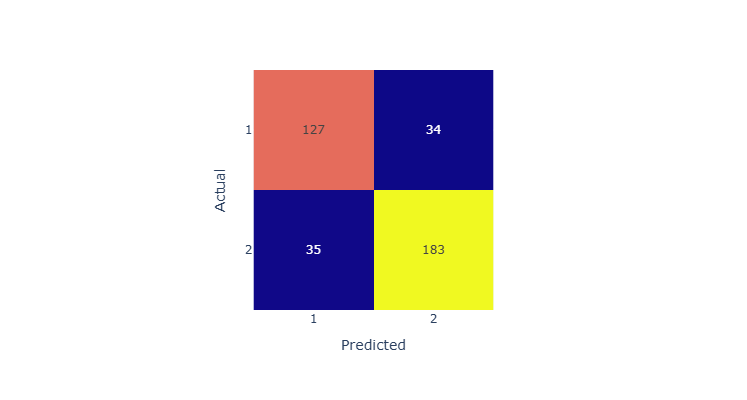

In [112]:
import plotly.express as px

#Count the unique target values
y_c = np.unique(np.concatenate([y_test, y_pred]))

#Calculate the accuracy as the number of rows where prediction matches actual value, divided by total number of rows in the validation set
acc = len(y_test[y_test == y_pred]) / len(y_test)

#Initializes an empty array to store the frequencies for the confusion matrix
confusion_matrix = np.zeros((len(y_c), len(y_c)))

#Stores the actual and predicted values in a 2d array, to make calculating the confusion matrix entries easier
ap = np.column_stack([y_test, y_pred])

#Iterates over the rows and columns of the confusion matrix
for actual in range(len(y_c)):
    for predicted in range(len(y_c)):
        #Each entry in the confusion matrix represents the number of entries of a given class that were predictted as the same/another class
        confusion_matrix[actual][predicted] = len(ap[(ap[:, 0] == y_c[actual]) & (ap[:, 1] == y_c[predicted])])

#Prints the accuracy and displays the confusion matrix array
print('Accuracy:', acc, '\n')
display(confusion_matrix)
print()

#Displays the confusion matrix using Plotly
fig = px.imshow(confusion_matrix, text_auto = True)
fig.update_layout(coloraxis_showscale=False, xaxis_title = 'Predicted', yaxis_title = 'Actual', height = 400, width = 400,
                 xaxis = dict(tickmode = 'array', tickvals = [i for i in range(len(y_c))], ticktext = [str(i+1) for i in range(len(y_c))]),
                 yaxis = dict(tickmode = 'array', tickvals = [i for i in range(len(y_c))], ticktext = [str(i+1) for i in range(len(y_c))]))
fig.show()

In [120]:
from scipy.stats import mode

def random_forest(x_train, y_train, x_test, n_trees, max_features, criterion = 'gini'):
    y_pred = np.zeros((n_trees, x_test.shape[0]), dtype=int)
    forest = []

    if criterion not in ['entropy', 'gini']:
        print("Invalid Criterion. Must be one of ('gini', 'entropy')")
        return -1
    
    for i in range(n_trees):
        #Selects rows with replacement (Bootstrap sampling) to train the current tree
        rows = np.random.choice(len(x_train), len(x_train), replace=True)
        
        #Selects the training data as the bootstrap-sampled rows and randomly-selected columns
        sample_x = x_train[rows]
        sample_y = y_train[rows]
    
        #Predicts class labels by training a decision tree on the selected rows and feature columns
        y_pred[i], tree = myDT(sample_x, sample_y, x_test, max_features, False, criterion)

    #Converts the predictions to a numpy array
    y_pred = np.array(y_pred).astype(int)
    forest.append(tree)

    #Calculates the most common prediction (mode) for each column
    final_pred = mode(y_pred, axis=0)[0]

    #Returns the majority predictions for each column
    return final_pred, forest

Accuracy: 0.9102902374670184 



array([[150.,  11.],
       [ 23., 195.]])

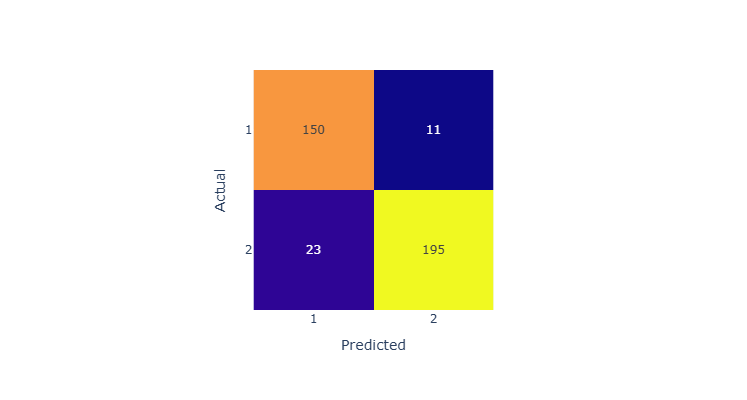

In [122]:
y_pred, forest = random_forest(x_train, y_train, x_test, 100, 'sqrt', 'gini')

acc = len(y_test[y_test == y_pred]) / len(y_test)

#Initializes an empty array to store the frequencies for the confusion matrix
confusion_matrix = np.zeros((len(y_c), len(y_c)))

#Stores the actual and predicted values in a 2d array, to make calculating the confusion matrix entries easier
ap = np.column_stack([y_test, y_pred])

#Iterates over the rows and columns of the confusion matrix
for actual in range(len(y_c)):
    for predicted in range(len(y_c)):
        #Each entry in the confusion matrix represents the number of entries of a given class that were predictted as the same/another class
        confusion_matrix[actual][predicted] = len(ap[(ap[:, 0] == y_c[actual]) & (ap[:, 1] == y_c[predicted])])

#Prints the accuracy and displays the confusion matrix array
print('Accuracy:', acc, '\n')
display(confusion_matrix)
print()

#Displays the confusion matrix using Plotly
fig = px.imshow(confusion_matrix, text_auto = True)
fig.update_layout(coloraxis_showscale=False, xaxis_title = 'Predicted', yaxis_title = 'Actual', height = 400, width = 400,
                 xaxis = dict(tickmode = 'array', tickvals = [i for i in range(len(y_c))], ticktext = [str(i+1) for i in range(len(y_c))]),
                 yaxis = dict(tickmode = 'array', tickvals = [i for i in range(len(y_c))], ticktext = [str(i+1) for i in range(len(y_c))]))
fig.show()

In [250]:
def get_tree_importance(tree, feature_names = feature_names):
    q = []
    importance = {}
    
    q.append(tree)
    
    while q:
        node = q.pop(0)
        if type(node) == dict:
            importance.setdefault(feature_names[node['feature']], 0)
            importance[feature_names[node['feature']]] += node['importance']
            
            if 'children' in node.keys():
                for i in node['children']:
                    q.append(node['children'][i])    
    
    return importance

dt_importance = get_tree_importance(dt)

In [252]:
def get_forest_importance(forest, feature_names = feature_names):
    importances = [get_feature_importance(tree, feature_names) for tree in forest]
    
    avg_importance = {}
    
    for i in importances:
        for feature in i:
            avg_importance.setdefault(feature, [])
            avg_importance[feature].append(float(i[feature]))
    
    for i in avg_importance:
        avg_importance[i] = np.mean(np.array(avg_importance[i]))
    
    return avg_importance

forest_importance = get_forest_importance(forest)

In [292]:
def plot_importance(importance, title):
    sorted_importance = dict(sorted(importance.items(), key = lambda x: x[1], reverse = True))
    i = np.array(list(sorted_importance.values()))
    i_norm = i / (i.sum())
    
    data = {
        'Feature': list(sorted_importance.keys()),
        'Importance': list(i_norm)
    }
    
    fig = px.bar(data, y = 'Importance', x = 'Feature', template = 'plotly_white', title = title)
    fig.update_layout(height = 600, width = 800)
    return fig

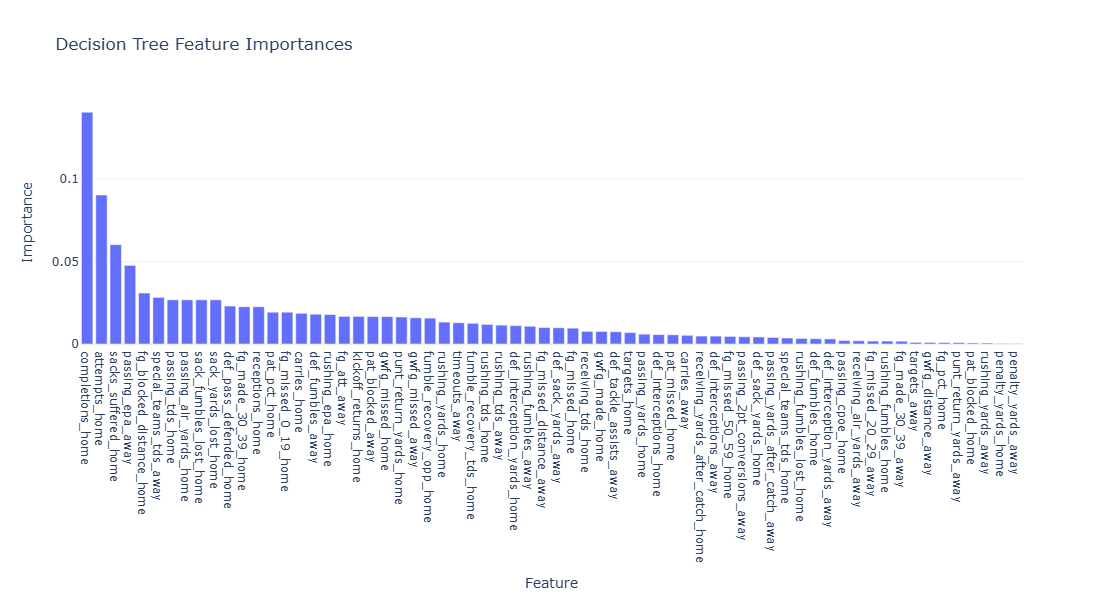

In [294]:
plot_importance(dt_importance, 'Decision Tree Feature Importances')

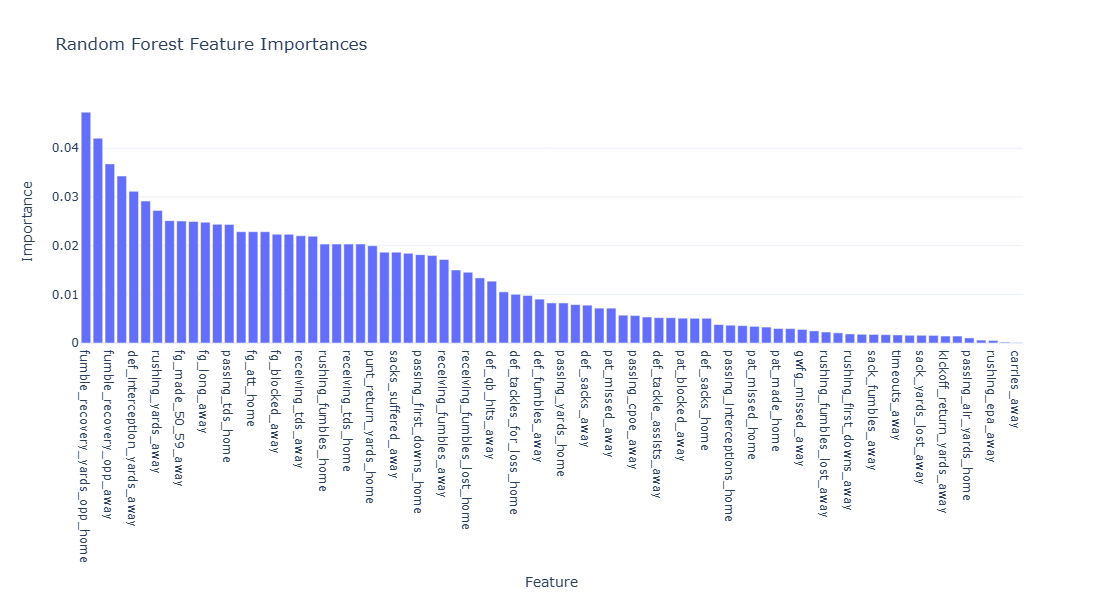

In [296]:
plot_importance(forest_importance, 'Random Forest Feature Importances')